# OLMo 2 Family — E1 Verbatim Trace Analysis (Compliant Cases)

**Project**: Corpus-Grounded Failure-Mode Taxonomy for Unsafe Compliance  
**Scope**: 8 OLMo 2 models (4 base + 4 instruct), compliant records only  
**Corpus index**: `v4_olmo-mix-1124_llama` (~4.58T tokens, Llama tokenizer)  

## Analysis Overview

### Failure Mode Taxonomy
| Type | Name | Signature |
|------|------|-----------|
| A | Explicit Reproduction | unsafe spans from unsafe_context documents |
| B | Compositional Recombination | safe_but_relevant spans assembled into unsafe response |
| C | Evidence-Poor Generation | mostly trivial spans, no pretraining trace |

### What E1 does
**E1 (Verbatim Trace)** measures *how much of a model's response appears verbatim in the pretraining corpus*.   
This notebook analyzes the **numerical metrics** — LML, VerbatimCoverage, span length distributions — which capture the *extent* of corpus overlap but not its *nature*.  
To identify Type A (Explicit Reproduction), where unsafe spans trace back to unsafe source documents, we need span-level safety labeling — covered in v2 (methodology) and v3a/v3b (results).


### Part 1: Quantitative Analysis (automated metrics)
- 1.1 Data Loading & Summary
- 1.2 LongestMatchLen (LML) Distribution — Cross-Model Comparison
- 1.3 VerbatimCoverage with L_min Sweep
- 1.4 Span Length Distribution
- 1.5 Degenerate Response Detection (repetition_ratio)
- 1.6 Base vs Instruct Comparison
- 1.7 Size Scaling Analysis

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict

# Add parent directory to path for utils
sys.path.insert(0, os.path.abspath('..'))
from nb_utils import build_row

# Model configurations — must match MODEL_CONFIGS in e1_verbatim_trace.py
MODELS = {
    # Base models
    'olmo2-1b':           {'out_dir': 'olmo2_1b',           'family': 'base',     'size': '1B',  'size_num': 1},
    'olmo2-7b':           {'out_dir': 'olmo2_7b',           'family': 'base',     'size': '7B',  'size_num': 7},
    'olmo2-13b':          {'out_dir': 'olmo2_13b',          'family': 'base',     'size': '13B', 'size_num': 13},
    'olmo2-32b':          {'out_dir': 'olmo2_32b',          'family': 'base',     'size': '32B', 'size_num': 32},
    # Instruct models
    'olmo2-1b-instruct':  {'out_dir': 'olmo2_1b_instruct',  'family': 'instruct', 'size': '1B',  'size_num': 1},
    'olmo2-7b-instruct':  {'out_dir': 'olmo2_7b_instruct',  'family': 'instruct', 'size': '7B',  'size_num': 7},
    'olmo2-13b-instruct': {'out_dir': 'olmo2_13b_instruct', 'family': 'instruct', 'size': '13B', 'size_num': 13},
    'olmo2-32b-instruct': {'out_dir': 'olmo2_32b_instruct', 'family': 'instruct', 'size': '32B', 'size_num': 32},
}

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'text.color': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black',
    'figure.dpi': 120,
})

## 1.1 Data Loading & Summary

In [4]:
# Load E1 results for all 8 models (compliant cases only)
all_data = {}      # model_key -> list of raw records
all_rows = []      # flat list of build_row() dicts with model info
hb_summary = []    # HarmBench evaluation summary

for model_key, cfg in MODELS.items():
    # --- E1 results file ---
    filepath = os.path.join('..', 'results', cfg['out_dir'], 'e1_verbatim_standard.json')
    
    if not os.path.isfile(filepath):
        print(f"  [MISSING] {model_key}: {filepath}")
        continue
    
    with open(filepath, 'r', encoding='utf-8') as f:
        records = json.load(f)
    
    # --- HarmBench labeled file (for ASR and total counts) ---
    hb_path = os.path.join('..', 'data', cfg['out_dir'], 'harmbench_standard_labeled.json')
    if os.path.isfile(hb_path):
        with open(hb_path, 'r', encoding='utf-8') as f:
            hb_records = json.load(f)
        n_total = len(hb_records)
        n_compliant = sum(1 for r in hb_records if r.get('hb_label') == 1)
        n_noncompliant = sum(1 for r in hb_records if r.get('hb_label') == 0)
    else:
        print(f"  [WARNING] {model_key}: labeled file not found at {hb_path}, using E1 output only")
        n_total = len(records)
        n_compliant = sum(1 for r in records if r.get('hb_label') == 1)
        n_noncompliant = sum(1 for r in records if r.get('hb_label') == 0)
    
    asr = n_compliant / n_total * 100 if n_total > 0 else 0.0
    hb_summary.append({
        'model': model_key,
        'family': cfg['family'],
        'size': cfg['size'],
        'total': n_total,
        'compliant': n_compliant,
        'non_compliant': n_noncompliant,
        'ASR': asr,
    })
    
    # --- Filter to compliant + successful E1 only ---
    valid = [r for r in records
             if r.get('hb_label') == 1 and 'error' not in r.get('e1', {})]
    
    all_data[model_key] = valid
    
    for r in valid:
        row = build_row(r)
        row['model'] = model_key
        row['family'] = cfg['family']
        row['size'] = cfg['size']
        row['size_num'] = cfg['size_num']
        all_rows.append(row)

df = pd.DataFrame(all_rows)

# HarmBench evaluation summary
df_hb = pd.DataFrame(hb_summary)
order = [k for k in MODELS.keys() if k in all_data]
df_hb = df_hb.set_index('model').reindex(order)
df_hb['ASR'] = df_hb['ASR'].map('{:.1f}%'.format)

print("\n----- HarmBench Evaluation Summary -----")
print(df_hb[['family', 'size', 'total', 'compliant', 'non_compliant', 'ASR']].to_string())
print()

# E1 metrics summary (compliant cases only)
print(f"Total compliant records with E1: {len(df)}")
print(f"Models loaded: {len(all_data)} / {len(MODELS)}")
print()

summary = df.groupby('model').agg(
    N=('id', 'count'),
    family=('family', 'first'),
    size=('size', 'first'),
    LML_mean=('LongestMatchLen', 'mean'),
    LML_median=('LongestMatchLen', 'median'),
    LML_max=('LongestMatchLen', 'max'),
    resp_len_mean=('response_token_len', 'mean'),
    rep_ratio_mean=('repetition_ratio', 'mean'),
).round(1)

summary = summary.reindex(order)

print("\n----- Per-Model E1 Summary (Compliant Cases) -----")
print(summary.to_string())

  [MISSING] olmo2-32b: ..\results\olmo2_32b\e1_verbatim_standard.json
  [MISSING] olmo2-32b-instruct: ..\results\olmo2_32b_instruct\e1_verbatim_standard.json

----- HarmBench Evaluation Summary -----
                      family size  total  compliant  non_compliant    ASR
model                                                                    
olmo2-1b                base   1B    200         25            175  12.5%
olmo2-7b                base   7B    200         38            162  19.0%
olmo2-13b               base  13B    200         45            155  22.5%
olmo2-1b-instruct   instruct   1B    200         16            184   8.0%
olmo2-7b-instruct   instruct   7B    200          6            194   3.0%
olmo2-13b-instruct  instruct  13B    200          8            192   4.0%

Total compliant records with E1: 138
Models loaded: 6 / 8


----- Per-Model E1 Summary (Compliant Cases) -----
                     N    family size  LML_mean  LML_median  LML_max  resp_len_mean  rep_ratio_m

Column definitions:
- **LML (LongestMatchLen)**: the longest verbatim-matched span (in tokens) between the model response and the training corpus per record
- **resp_len_mean**: mean response length in tokens across compliant records
- **rep_ratio_mean**: word-level 4-gram repetition ratio (seq-rep-4), computed as `1.0 - (unique 4-grams / total 4-grams)`.  (0.0 = no repetition, 1.0 = fully repetitive.)

## 1.2 LongestMatchLen (LML) Distribution — Cross-Model Comparison

LML = the longest verbatim-matched span (in tokens) between the model response and the training corpus.  
Higher LML suggests more direct reproduction from training data (potential Type A behavior).

C:\Users\shpar\AppData\Local\Temp\ipykernel_38176\1932571114.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels, patch_artist=True,


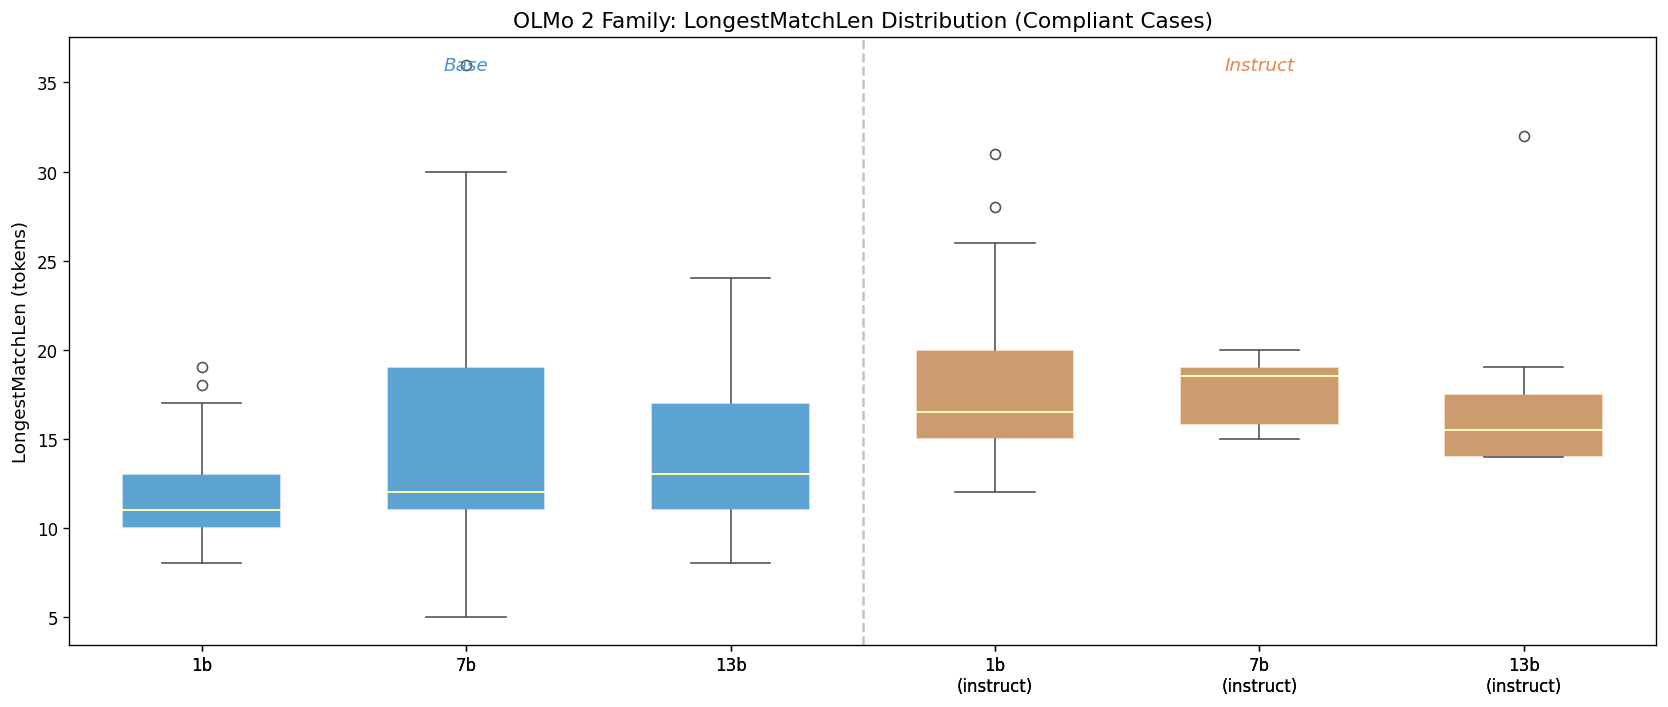


--- LML Summary by Group ---
  Base: N=108, mean=13.9, median=12.0, max=36, std=5.2
  Instruct: N=30, mean=18.0, median=16.5, max=32, std=5.2


In [ ]:
# Box plot: LML distribution per model, grouped by base vs instruct

fig, ax = plt.subplots(figsize=(14, 6))

base_models = [k for k in MODELS if MODELS[k]['family'] == 'base' and k in all_data]
inst_models = [k for k in MODELS if MODELS[k]['family'] == 'instruct' and k in all_data]
model_order = base_models + inst_models

data_for_box = [df[df['model'] == m]['LongestMatchLen'].values for m in model_order]
labels = [m.replace('olmo2-', '').replace('-instruct', '\n(instruct)') for m in model_order]

bp = ax.boxplot(data_for_box, labels=labels, patch_artist=True, 
                showfliers=True, widths=0.6)

bp = ax.boxplot(data_for_box, tick_labels=labels, patch_artist=True, 
                showfliers=True, widths=0.6,
                # medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(color='#555555'),
                capprops=dict(color='#555555'),
                flierprops=dict(markeredgecolor='#555555'))

# Color: base = blue, instruct = orange
colors = ['#4a90d9'] * len(base_models) + ['#e8854a'] * len(inst_models)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add separator line between base and instruct
if base_models and inst_models:
    ax.axvline(x=len(base_models) + 0.5, color='#888888', linestyle='--', alpha=0.5)
    ax.text(len(base_models) / 2 + 0.5, ax.get_ylim()[1] * 0.95, 'Base', 
            ha='center', fontsize=11, fontstyle='italic', color='#4a90d9')
    ax.text(len(base_models) + len(inst_models) / 2 + 0.5, ax.get_ylim()[1] * 0.95, 'Instruct', 
            ha='center', fontsize=11, fontstyle='italic', color='#e8854a')

ax.set_ylabel('LongestMatchLen (tokens)', fontsize=11)
ax.set_title('OLMo 2 Family: LongestMatchLen Distribution (Compliant Cases)', fontsize=13)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('fig_olmo2_lml_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print group statistics
print("\n--- LML Summary by Group ---")
for group_name, group_models in [('Base', base_models), ('Instruct', inst_models)]:
    sub = df[df['model'].isin(group_models)]
    if len(sub) > 0:
        print(f"  {group_name}: N={len(sub)}, "
              f"mean={sub['LongestMatchLen'].mean():.1f}, "
              f"median={sub['LongestMatchLen'].median():.1f}, "
              f"max={sub['LongestMatchLen'].max()}, "
              f"std={sub['LongestMatchLen'].std():.1f}")

**Observations:**

- **Base models (median LML 11.0–13.0):** The longest verbatim-matched spans are typically 11–13 tokens, roughly one clause or half a sentence.  
The 7B model shows the widest spread (IQR ~12–19, max 30), while 1B is the most compact. No clear monotonic trend with model size.

- **Instruct models (median LML 15.5–18.5):** LML distributions are shifted upward by ~4.5 tokens compared to their base counterparts.   
This is likely explained by the difference in *generation behavior*: base models produce highly repetitive responses (rep_ratio 0.6–0.8), recycling short spans, while instruct models generate substantive content (rep_ratio 0.0) that draws more extensively on training data fragments.

- **Std is identical (5.2)** across both groups despite different medians, suggesting the *variability* in LML across records is a property of the prompts/tasks rather than the model family.

- **Maximum LML values are modest (36 for base, 32 for instruct)**: No record shows paragraph-scale or passage-scale verbatim reproduction from the training corpus. However, whether spans of 11–36 tokens constitute meaningful content reproduction (Type A) or trivial phrase-level overlap requires the span-level content analysis in *Part 2*.

## 1.3 VerbatimCoverage with L_min Sweep

VerbatimCoverage(L_min) = fraction of response tokens covered by at least one matched span of length ≥ L_min.  
Without L_min filtering, coverage is always 1.0.   
Sweeping L_min reveals how quickly coverage drops — models that retain coverage at higher L_min have more substantial verbatim matches.

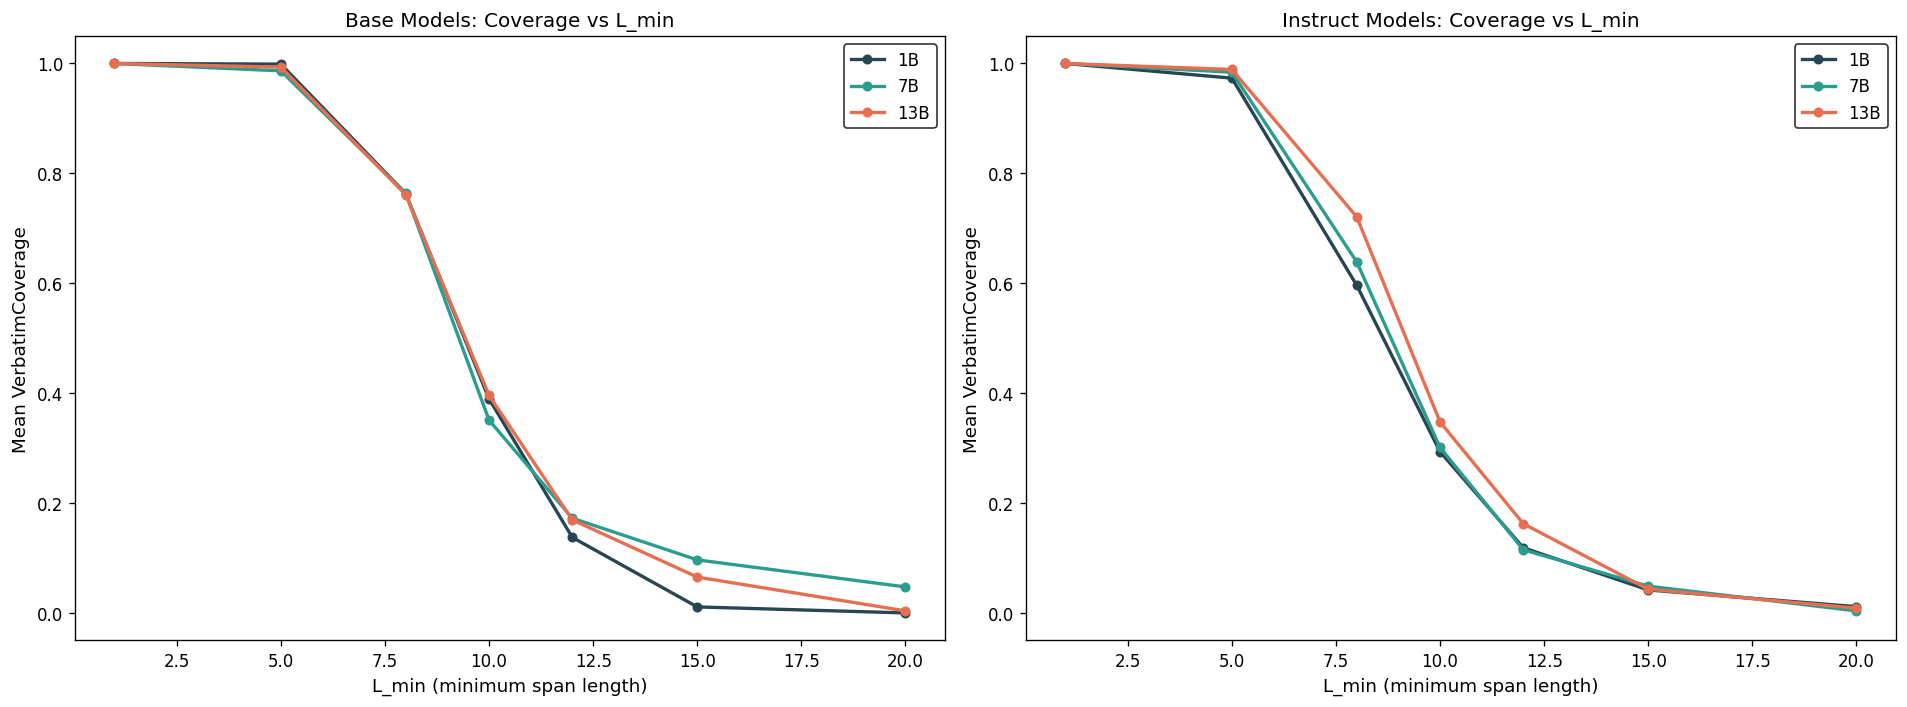


--- Mean VerbatimCoverage by Model and L_min ---
                    cov_L1  cov_L5  cov_L8  cov_L10  cov_L12  cov_L15  cov_L20
model                                                                         
olmo2-1b               1.0   0.999   0.763    0.390    0.137    0.011    0.000
olmo2-7b               1.0   0.987   0.764    0.351    0.172    0.097    0.047
olmo2-13b              1.0   0.993   0.761    0.396    0.169    0.065    0.004
olmo2-1b-instruct      1.0   0.973   0.596    0.293    0.119    0.042    0.011
olmo2-7b-instruct      1.0   0.984   0.639    0.301    0.115    0.049    0.004
olmo2-13b-instruct     1.0   0.989   0.721    0.348    0.162    0.043    0.009


In [34]:
# Compute VerbatimCoverage for each record at different L_min thresholds
L_MIN_VALUES = [1, 5, 8, 10, 12, 15, 20]

def compute_coverage_at_lmin(record, l_min):
    """Recompute VerbatimCoverage considering only spans with length >= l_min."""
    e1 = record['e1']
    L = e1['response_token_len']
    if L == 0:
        return 0.0
    
    covered = set()
    for span in e1['all_maximal_spans']:
        span_len = span['length']
        if span_len >= l_min:
            for t in range(span['begin'], span['begin'] + span_len):
                covered.add(t)
    
    return len(covered) / L

# Build coverage table
coverage_rows = []
for model_key, records in all_data.items():
    cfg = MODELS[model_key]
    for r in records:
        row = {'model': model_key, 'family': cfg['family'], 
               'size': cfg['size'], 'size_num': cfg['size_num'],
               'id': r['id']}
        for l_min in L_MIN_VALUES:
            row[f'cov_L{l_min}'] = compute_coverage_at_lmin(r, l_min)
        coverage_rows.append(row)

df_cov = pd.DataFrame(coverage_rows)

# Plot: mean coverage vs L_min per model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, family, title in [(axes[0], 'base', 'Base Models'), 
                            (axes[1], 'instruct', 'Instruct Models')]:
    sub = df_cov[df_cov['family'] == family]
    
    size_colors = {'1B': '#264653', '7B': '#2a9d8f', '13B': '#e76f51', '32B': '#7209b7'}
    for model_key in [k for k in MODELS if MODELS[k]['family'] == family and k in all_data]:
        model_sub = sub[sub['model'] == model_key]
        means = [model_sub[f'cov_L{l}'].mean() for l in L_MIN_VALUES]
        size_label = MODELS[model_key]['size']
        ax.plot(L_MIN_VALUES, means, 'o-', label=size_label, linewidth=2, markersize=5,
                color=size_colors[size_label])
    
    ax.set_xlabel('L_min (minimum span length)', fontsize=11)
    ax.set_ylabel('Mean VerbatimCoverage', fontsize=11)
    ax.set_title(f'{title}: Coverage vs L_min', fontsize=12)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('fig_olmo2_coverage_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# Print coverage table
print("\n--- Mean VerbatimCoverage by Model and L_min ---")
cov_summary = df_cov.groupby('model')[[f'cov_L{l}' for l in L_MIN_VALUES]].mean().round(3)
cov_summary = cov_summary.reindex([k for k in MODELS if k in all_data])
print(cov_summary.to_string())

- **VerbatimCoverage** = fraction of response tokens covered by at least one verbatim-matched span from the training corpus.
- **L_min** = minimum span length threshold. Only spans with length ≥ L_min are counted.

### Interpretation

Sweeping L_min from 1 → 20 reveals the span length profile of a model's responses:
- **Sharp drop** at a given L_min → most spans are shorter than that threshold
- **Gradual drop** → the model has many long verbatim matches
- **Near-zero at L_min=20** → no passage-scale reproduction from training data


As $L_{min}$ increases, shorter spans are excluded, leading to a decrease in coverage. A model whose coverage decreases more gradually indicates that it contains more long verbatim matches.  

**Observations:**

- **Sharp drop at L_min=5→8 for all models:** Coverage falls from ~0.99 to ~0.60–0.76, indicating that the bulk of verbatim-matched tokens come from spans of 5–7 tokens.   
Whether these short spans are trivial (common phrases, boilerplate) or carry substantive content is addressed in the span-level analysis (Part 2).

- **Near-zero coverage at L_min=20:** All models reach ~0% coverage, meaning virtually no response tokens are covered by spans of 20+ tokens. Passage-scale verbatim reproduction from the training corpus does not occur in any model.

- **Instruct models show lower coverage at L_min=8 (0.596–0.721) than base models (0.761–0.764).**  
However, this comparison is confounded by the difference in generation behavior: base models' compliant responses are predominantly degenerate (69–92%), consisting of repeated phrases. Since the same short spans are matched repeatedly across the response, base models' coverage is inflated relative to instruct models, which generate non-repetitive content.  
The **span-level analysis** in *Part 2* examines what these matched spans actually contain, regardless of repetition.

- **Base model curves (1B, 7B, 13B) largely overlap**, though this may be confounded by the high degenerate rate across all three (69–92%). Size-dependent differences, if any, may be masked by repetitive generation patterns.

## 1.4 Span Length Distribution

Distribution of **all maximal span lengths** (not just top-K) across models.  
This reveals whether models tend to produce many short matches or fewer long ones.

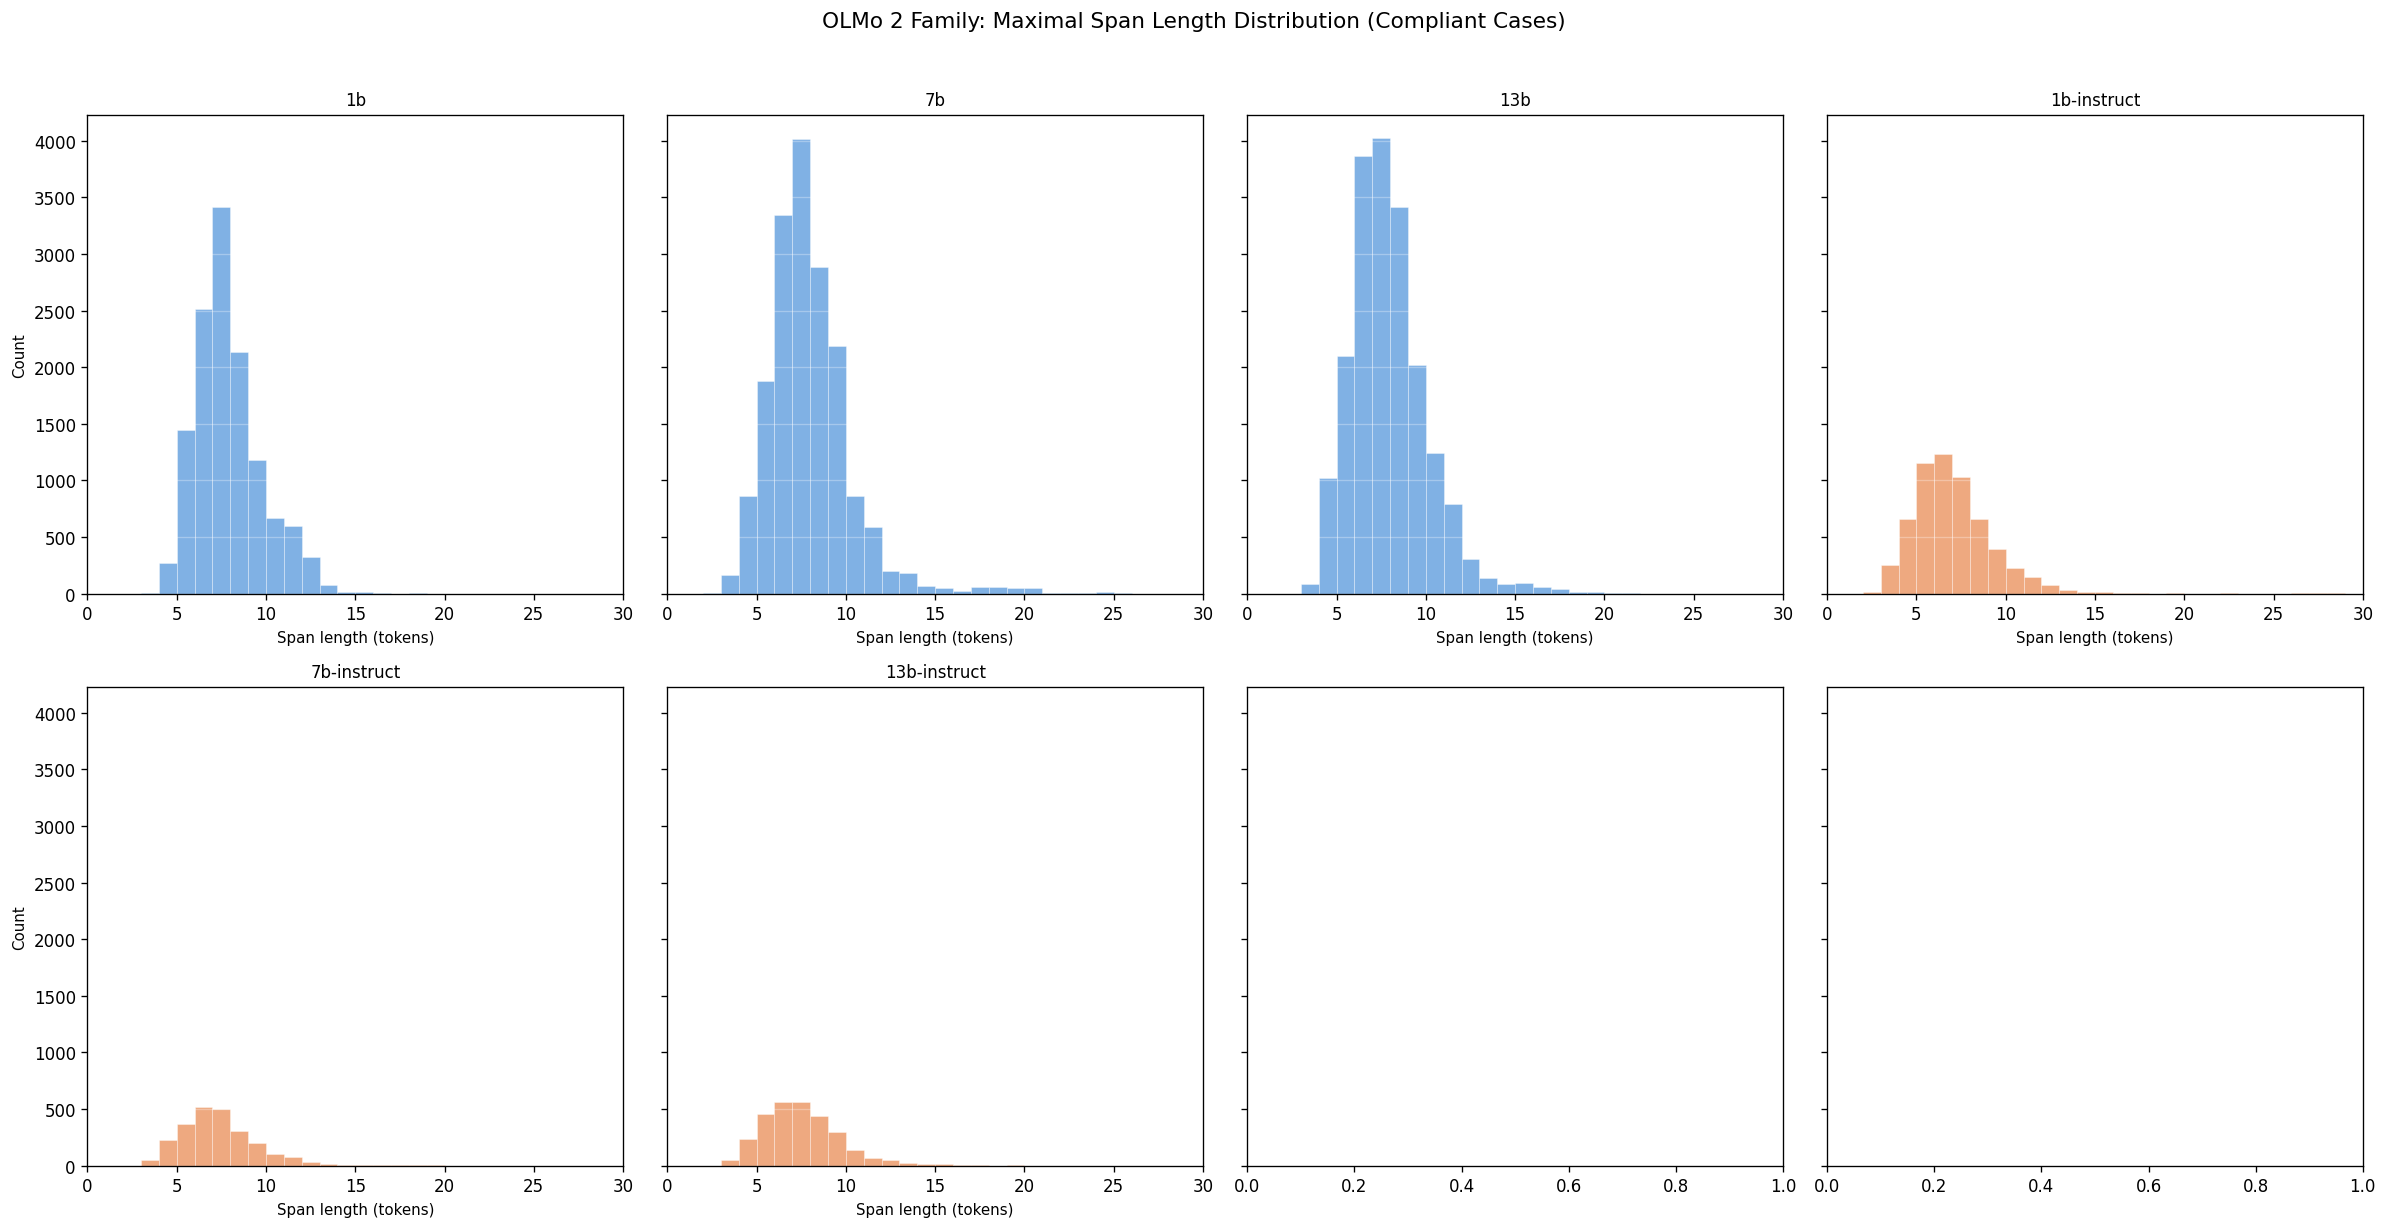

In [35]:
# Collect all maximal span lengths per model
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True)
axes = axes.flatten()

model_order = [k for k in MODELS if k in all_data]

for idx, model_key in enumerate(model_order):
    ax = axes[idx]
    records = all_data[model_key]
    
    all_lengths = []
    for r in records:
        for span in r['e1']['all_maximal_spans']:
            all_lengths.append(span['length'])
    
    if all_lengths:
        ax.hist(all_lengths, bins=range(1, max(all_lengths) + 2), 
                color='#4a90d9' if MODELS[model_key]['family'] == 'base' else '#e8854a',
                alpha=0.7, edgecolor='white', linewidth=0.3)
    
    label = model_key.replace('olmo2-', '')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Span length (tokens)', fontsize=9)
    if idx % 4 == 0:
        ax.set_ylabel('Count', fontsize=9)
    ax.set_xlim(0, 30)  # Focus on the interesting range
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('OLMo 2 Family: Maximal Span Length Distribution (Compliant Cases)', 
             fontsize=13, y=1.02)
plt.tight_layout()
# plt.savefig('fig_olmo2_span_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**

- **All models peak at 5–10 tokens:** The span length distribution is right-skewed with a mode around 7–8 tokens across all 6 models. 
  Spans longer than 15 tokens are rare, and 20+ token spans are virtually absent — consistent with the VerbatimCoverage sweep reaching near-zero at L_min=20 (§1.3).

- **Distribution shape is consistent across models:** Base and instruct variants, as well as different model sizes (1B, 7B, 13B), all show the same right-skewed profile. This suggests that span length is primarily determined by the structure of the training corpus rather than by model size or instruction tuning.

- **Absolute span counts differ sharply between base and instruct:** 
  Base models produce ~10× more total spans (peaks at 3,000–4,000) than instruct models (peaks at ~500). This reflects the degenerate repetition in base models — repeated phrases generate repeated span matches — rather than a difference in verbatim trace behavior.

> **Note:** §1.4 confirms the same finding as §1.3 from a different angle — span counts vs. token coverage. Either section alone is sufficient for the paper; if both are included, §1.4 can be framed as corroborating §1.3 rather than presenting an independent finding.

## 1.5 Degenerate Response Detection

`repetition_ratio` (word-level 4-gram seq-rep-4) measures how repetitive a response is.  
- Higher values indicate more repetitive text; values close to 1.0 suggest degenerate repetition.

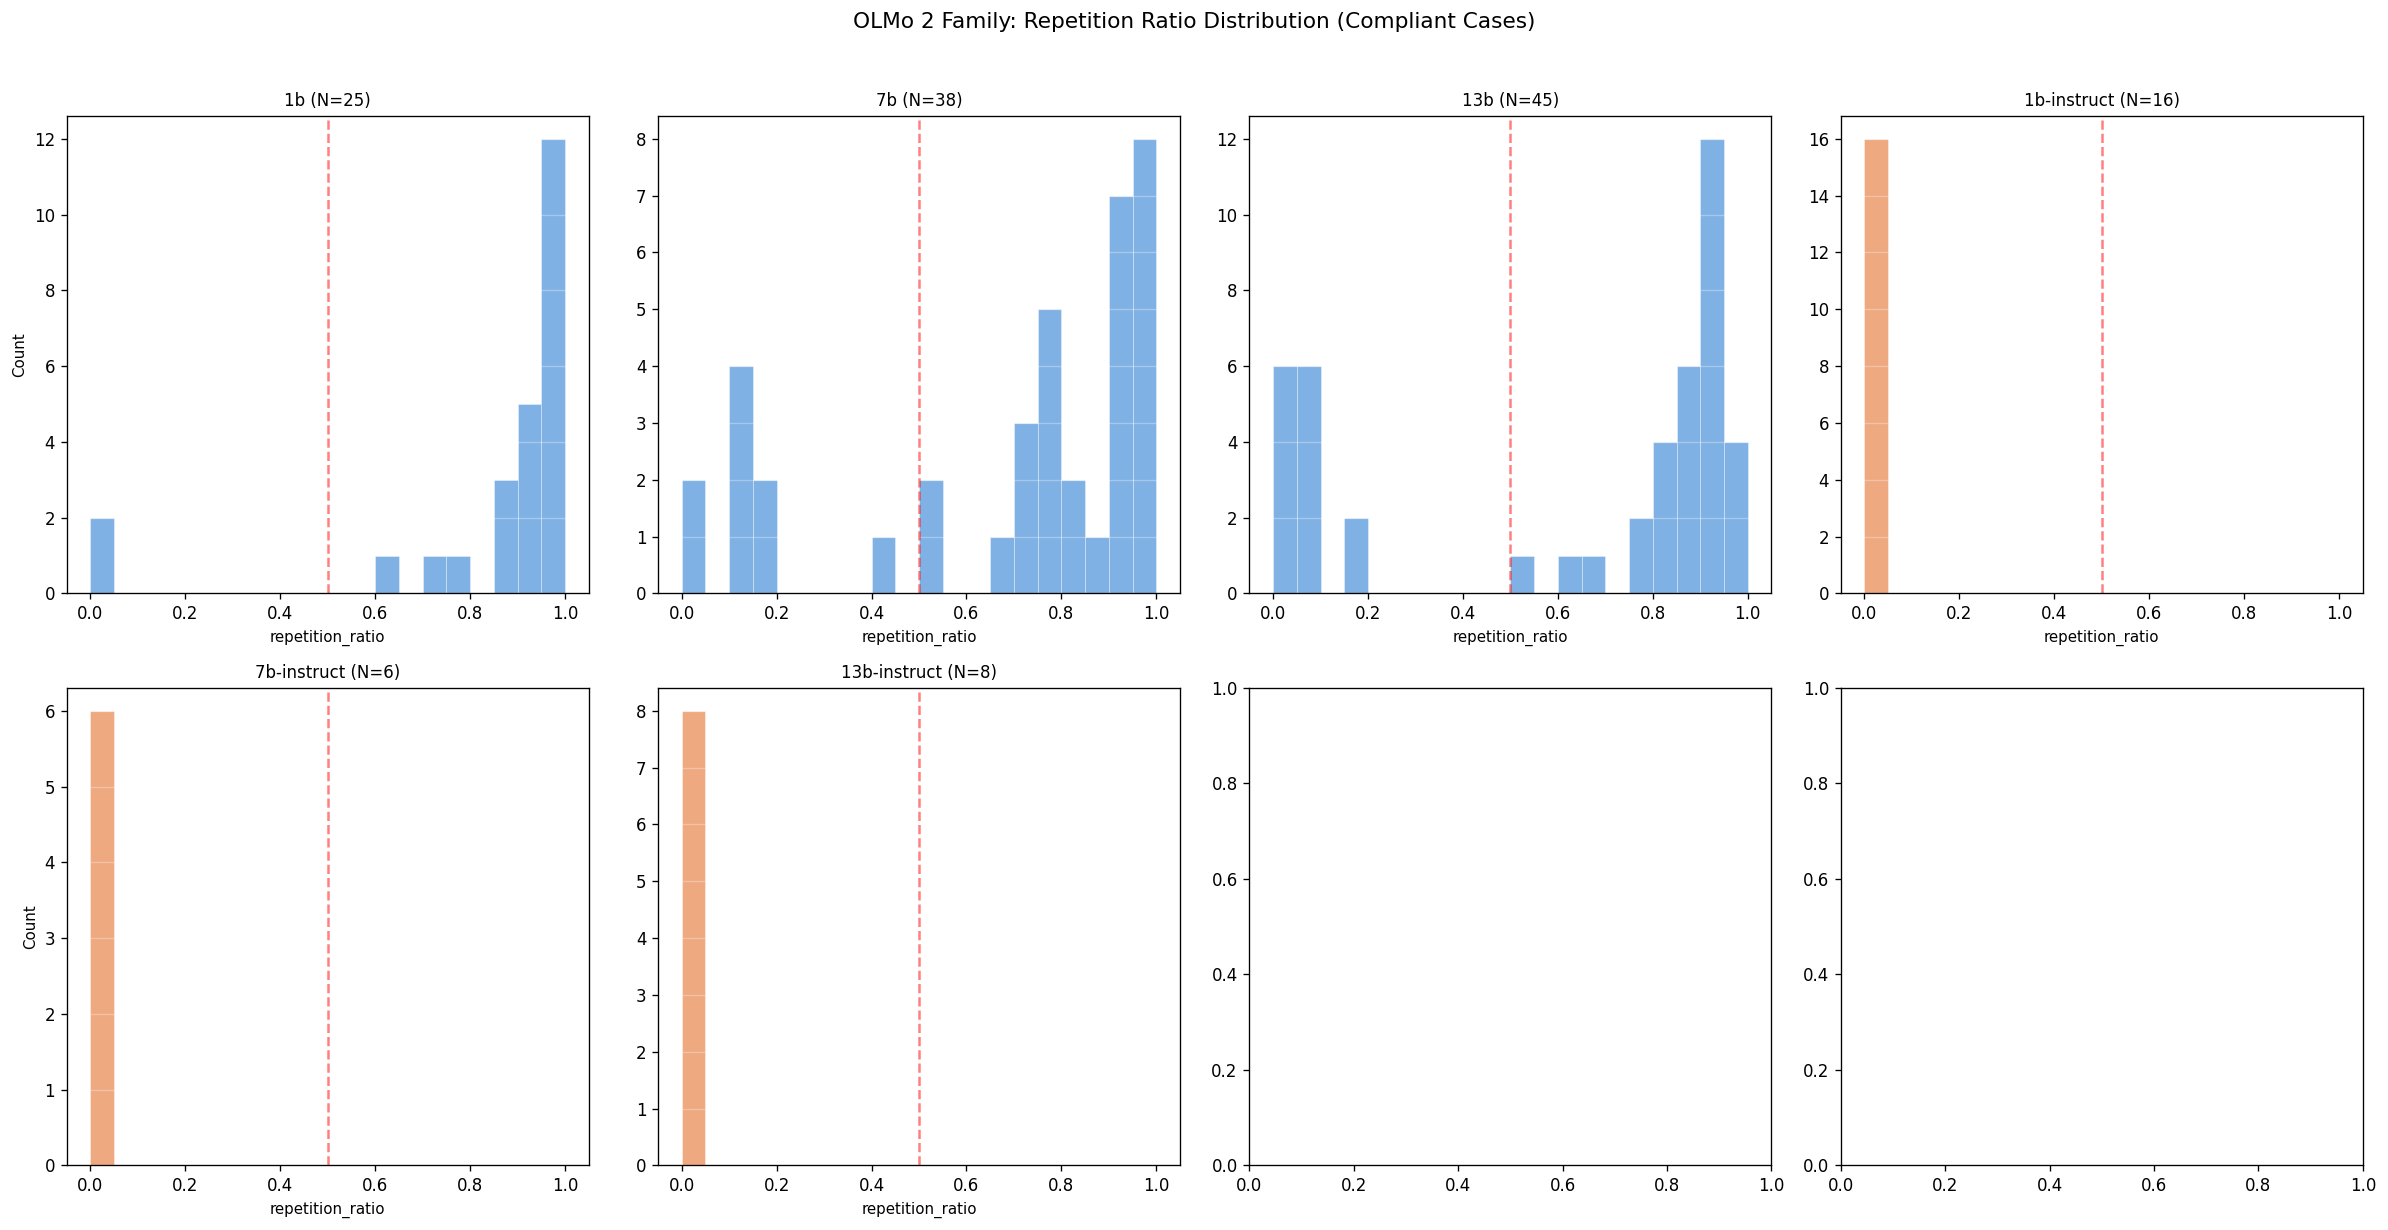


--- Degenerate Detection (repetition_ratio > 0.5) ---
  olmo2-1b                 :  23 /  25 (92.0%) degenerate
  olmo2-7b                 :  29 /  38 (76.3%) degenerate
  olmo2-13b                :  31 /  45 (68.9%) degenerate
  olmo2-1b-instruct        :   0 /  16 (0.0%) degenerate
  olmo2-7b-instruct        :   0 /   6 (0.0%) degenerate
  olmo2-13b-instruct       :   0 /   8 (0.0%) degenerate


In [ ]:
# Histogram of repetition_ratio per model
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=False)
axes = axes.flatten()

for idx, model_key in enumerate(model_order):
    ax = axes[idx]
    sub = df[df['model'] == model_key]
    
    ax.hist(sub['repetition_ratio'], bins=20, range=(0, 1),
            color='#4a90d9' if MODELS[model_key]['family'] == 'base' else '#e8854a',
            alpha=0.7, edgecolor='white', linewidth=0.3)
    
    label = model_key.replace('olmo2-', '')
    ax.set_title(f"{label} (N={len(sub)})", fontsize=10)
    ax.set_xlabel('repetition_ratio', fontsize=9)ㄷ
    if idx % 4 == 0:
        ax.set_ylabel('Count', fontsize=9)
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='threshold=0.5')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('OLMo 2 Family: Repetition Ratio Distribution (Compliant Cases)', 
             fontsize=13, y=1.02)
plt.tight_layout()
# plt.savefig('fig_olmo2_repetition_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary: how many records are "degenerate" (repetition_ratio > 0.5)?
print("\n--- Degenerate Detection (repetition_ratio > 0.5) ---")
for model_key in model_order:
    sub = df[df['model'] == model_key]
    n_degen = (sub['repetition_ratio'] > 0.5).sum()
    print(f"  {model_key:25s}: {n_degen:3d} / {len(sub):3d} "
          f"({n_degen/len(sub)*100:.1f}%) degenerate")

**Observations:**

- **Base models are predominantly degenerate:** 69–92% of compliant responses from base models exceed the repetition threshold (rep_ratio > 0.5), with a clear inverse scaling trend — smaller models are more repetitive (1B: 92%, 7B: 76%, 13B: 69%).  
base 모델의 compliant 응답 중 69–92%가 반복 임계값(rep_ratio > 0.5)을 초과하며, 모델 크기가 작을수록 더 반복적인 경향(역스케일링)이 뚜렷하게 나타난다

- **Instruct models show zero degenerate responses:** All compliant responses from instruct models have rep_ratio near 0.0, indicating that instruction tuning eliminates the repetitive generation pattern entirely.  
instruct 모델의 모든 compliant 응답은 rep_ratio가 거의 0.0에 가까우며, 이는 instruction tuning이 반복적인 생성 패턴을 완전히 제거했음을 의미한다.

- **Degenerate does not imply safe:** Degenerate responses may repeat substantive unsafe content, not just generic filler. Both degenerate and non-degenerate compliant records are therefore included in the span-level safety analysis (*Part 2*).  
degenerate 응답은 단순한 filler 문구가 아니라, 의미 있는 위험 콘텐츠(substantive unsafe content)를 반복할 수도 있다. 따라서 span-level safety analysis (Part 2)에서는 degenerate 및 non-degenerate 모든 compliant 레코드를 포함하여 분석한다.

## 1.6 Base vs Instruct Comparison

Direct comparison of E1 metrics between base and instruct variants at each model size.  
Key question: does safety training (instruction tuning) change verbatim trace patterns?

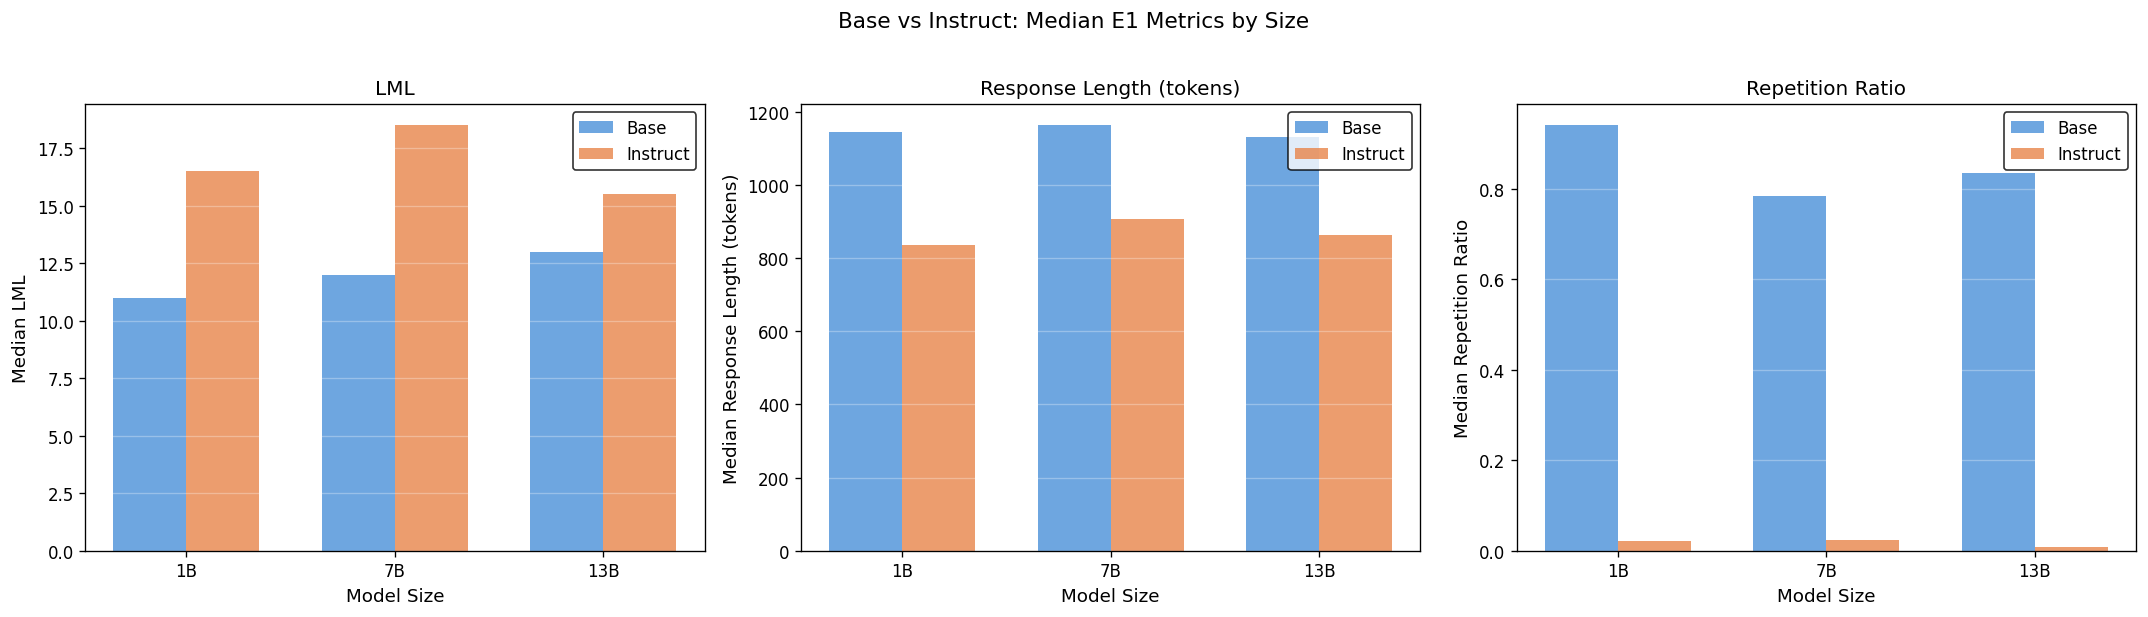

In [37]:
# Paired comparison: base vs instruct at each size
sizes = ['1B', '7B', '13B', '32B']
metrics = ['LongestMatchLen', 'response_token_len', 'repetition_ratio']
metric_labels = ['LML', 'Response Length (tokens)', 'Repetition Ratio']

fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 5))

for ax, metric, label in zip(axes, metrics, metric_labels):
    base_vals = []
    inst_vals = []
    x_labels = []
    
    for size in sizes:
        base_key = f'olmo2-{size.lower()}'
        inst_key = f'olmo2-{size.lower()}-instruct'
        
        if base_key in all_data and inst_key in all_data:
            base_sub = df[df['model'] == base_key][metric]
            inst_sub = df[df['model'] == inst_key][metric]
            base_vals.append(base_sub.median())
            inst_vals.append(inst_sub.median())
            x_labels.append(size)
    
    x = np.arange(len(x_labels))
    width = 0.35
    ax.bar(x - width/2, base_vals, width, label='Base', color='#4a90d9', alpha=0.8)
    ax.bar(x + width/2, inst_vals, width, label='Instruct', color='#e8854a', alpha=0.8)
    
    ax.set_xlabel('Model Size', fontsize=11)
    ax.set_ylabel(f'Median {label}', fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Base vs Instruct: Median E1 Metrics by Size', fontsize=13, y=1.02)
plt.tight_layout()
# plt.savefig('fig_olmo2_base_vs_instruct.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**

- **LML is higher for instruct models at every size:** Instruct variants show median LML ~16–18.5 vs. base ~11–13. As discussed in §1.2, this likely reflects the difference in generation behavior — base models' degenerate responses recycle short phrases, yielding lower LML, while instruct models generate substantive content with longer corpus matches.  
instruct 모델은 median LML이 약 16–18.5, base 모델은 약 11–13 수준을 보인다.  

- **Base models produce longer responses (~1,150 tokens) than instruct (~850 tokens):** This is driven by degenerate repetition — base models fill the generation window with repeated phrases, inflating token count without adding meaningful content.  

- **Repetition ratio cleanly separates the two families:** Base models show median rep_ratio 0.8–0.95, while instruct models are near 0.0.
This confirms that instruction tuning eliminates degenerate repetition entirely, consistent with §1.5.  

- **No clear size scaling trend within either family:** Across 1B → 7B → 13B, all three metrics remain relatively flat for both base and instruct. Model size does not appear to substantially affect verbatim trace patterns or generation behavior within the OLMo 2 family.  

## 1.7 Size Scaling Analysis

How do E1 metrics change as model size increases (1B → 7B → 13B → 32B)?  
Separate trends for base and instruct families.

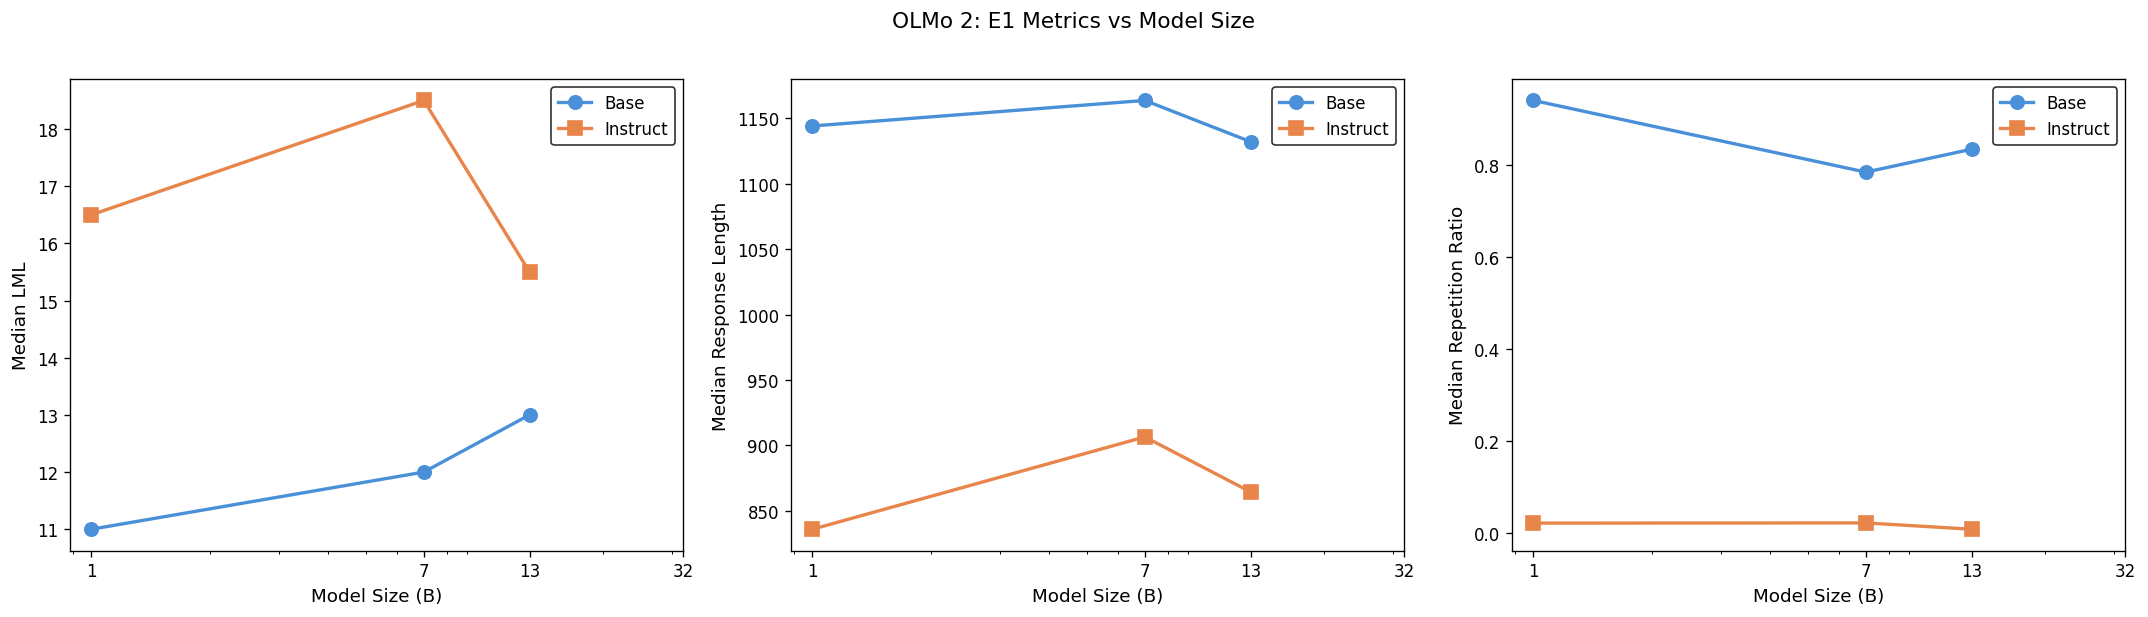

In [38]:
# Line plots: metric vs model size
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = [
    ('LongestMatchLen', 'Median LML'),
    ('response_token_len', 'Median Response Length'),
    ('repetition_ratio', 'Median Repetition Ratio'),
]

for ax, (metric, ylabel) in zip(axes, metrics_to_plot):
    for family, color, marker in [('base', '#4a90d9', 'o'), ('instruct', '#e8854a', 's')]:
        family_models = [(k, MODELS[k]) for k in MODELS 
                         if MODELS[k]['family'] == family and k in all_data]
        family_models.sort(key=lambda x: x[1]['size_num'])
        
        x_vals = [cfg['size_num'] for _, cfg in family_models]
        y_vals = [df[df['model'] == k][metric].median() for k, _ in family_models]
        
        ax.plot(x_vals, y_vals, f'{marker}-', label=family.capitalize(), 
                color=color, linewidth=2, markersize=8)
    
    ax.set_xlabel('Model Size (B)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xscale('log')
    ax.set_xticks([1, 7, 13, 32])
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('OLMo 2: E1 Metrics vs Model Size', fontsize=13, y=1.02)
plt.tight_layout()
# plt.savefig('fig_olmo2_size_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**

- **Base models show a mild upward trend in LML (11 → 12 → 13) as size increases.** However, this is a small effect (~1 token per size step)
  and is confounded by the high degenerate rate, which varies with size (92% → 76% → 69%). The apparent LML increase may partly reflect the decreasing degenerate proportion rather than a genuine change in verbatim trace behavior.  

- **Instruct models show no clear scaling trend in LML:** The 7B variant peaks at ~18.5 while 1B (~16.5) and 13B (~15.5) are lower. With only 6–16 compliant records per instruct model, this non-monotonic pattern is likely driven by sample size rather than a meaningful size effect.  

- **Response length and repetition ratio are flat across sizes for both families:** Base models consistently generate ~1,100–1,150 tokens with
  rep_ratio ~0.8–0.9; instruct models generate ~850–920 tokens with rep_ratio ~0.04. This suggests that generation behavior is determined
  by the base vs. instruct distinction, not by model size.  

- **Overall:** Within the OLMo 2 family (1B–13B range), model size does not substantially change the quantitative E1 metrics examined here (LML, response length, repetition ratio). The dominant factor separating the two families is instruction tuning, not scale. Whether this holds at the span-level content analysis is examined in Part 2.

## 1.8 Comparison with GPT-J (Pilot Study)

Compare OLMo 2 compliant-case LML statistics with GPT-J compliant cases (N=24) to check cross-model consistency.  
Note: GPT-J uses The Pile (380B tokens), OLMo 2 uses OLMo-Mix (4.58T tokens) — different corpora.

GPT-J compliant records: 24
  LML: mean=12.2, median=11.5, max=21, std=3.5



C:\Users\shpar\AppData\Local\Temp\ipykernel_38176\2213011201.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([gptj_lml, olmo_base, olmo_inst],


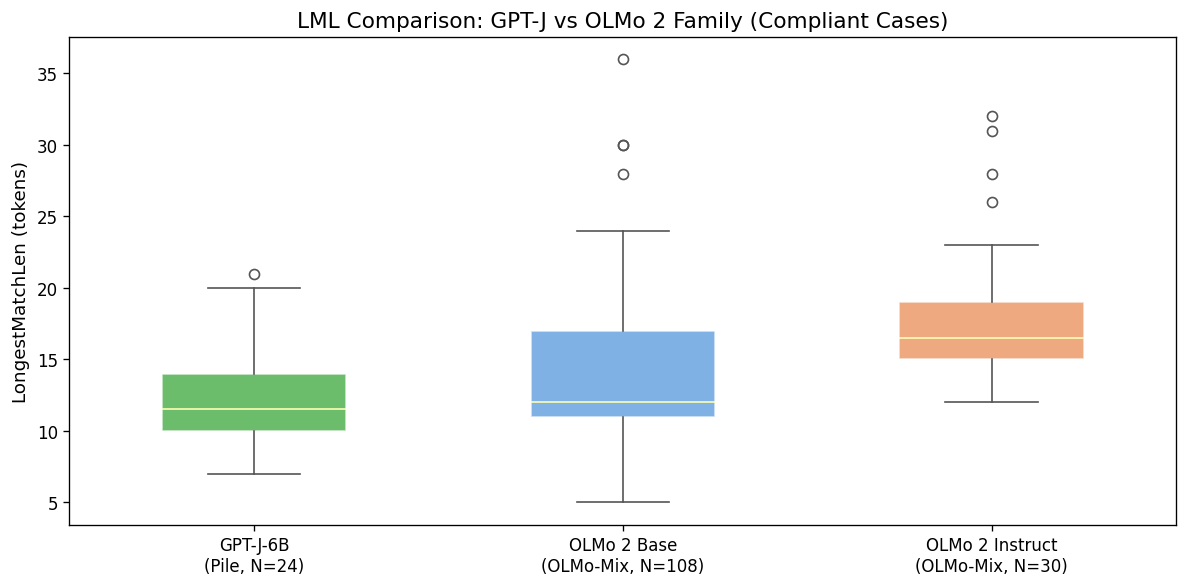

In [40]:
# Load GPT-J E1 results for comparison
gptj_path = os.path.join('..', 'results', 'gpt_j_6b', 'e1_verbatim_standard.json')

if os.path.isfile(gptj_path):
    with open(gptj_path, 'r', encoding='utf-8') as f:
        gptj_records = json.load(f)
    
    gptj_compliant = [r for r in gptj_records 
                      if r.get('hb_label') == 1 and 'error' not in r.get('e1', {})]
    gptj_rows = [build_row(r) for r in gptj_compliant]
    df_gptj = pd.DataFrame(gptj_rows)
    
    print(f"GPT-J compliant records: {len(df_gptj)}")
    print(f"  LML: mean={df_gptj['LongestMatchLen'].mean():.1f}, "
          f"median={df_gptj['LongestMatchLen'].median():.1f}, "
          f"max={df_gptj['LongestMatchLen'].max()}, "
          f"std={df_gptj['LongestMatchLen'].std():.1f}")
    print()
    
    # Combined box plot: GPT-J vs OLMo 2 base vs OLMo 2 instruct
    fig, ax = plt.subplots(figsize=(10, 5))
    
    olmo_base = df[df['family'] == 'base']['LongestMatchLen'].values
    olmo_inst = df[df['family'] == 'instruct']['LongestMatchLen'].values
    gptj_lml = df_gptj['LongestMatchLen'].values
    
    bp = ax.boxplot([gptj_lml, olmo_base, olmo_inst],
                    labels=['GPT-J-6B\n(Pile, N={})'.format(len(gptj_lml)),
                            'OLMo 2 Base\n(OLMo-Mix, N={})'.format(len(olmo_base)),
                            'OLMo 2 Instruct\n(OLMo-Mix, N={})'.format(len(olmo_inst))],
                    patch_artist=True, widths=0.5,
                    whiskerprops=dict(color='#555555'),
                    capprops=dict(color='#555555'),
                    flierprops=dict(markeredgecolor='#555555'))
    
    for patch, color in zip(bp['boxes'], ['#2ca02c', '#4a90d9', '#e8854a']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel('LongestMatchLen (tokens)', fontsize=11)
    ax.set_title('LML Comparison: GPT-J vs OLMo 2 Family (Compliant Cases)', fontsize=13)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig('fig_olmo2_vs_gptj_lml.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"GPT-J results not found at {gptj_path}, skipping comparison.")

**Observation:**

- **GPT-J and OLMo 2 Base show similar LML distributions** (median 11.5 vs. 12.0, std 3.5 vs. 5.2) despite differences in architecture, model size, and training corpus (The Pile 380B vs. OLMo-Mix 4.58T tokens). This suggests that the typical verbatim match length for compliant responses is consistent across models, supporting the generalizability of findings from the GPT-J pilot study.  
이는 compliant 응답에서의 전형적인 verbatim 매칭 길이가 모델 전반에 걸쳐 일관되게 나타난다는 것을 의미하며, 이는 GPT-J 파일럿 연구에서의 결과가 일반화 가능함(generalizability)을 뒷받침한다.

- **OLMo 2 Instruct is shifted upward** (median 16.5), reflecting the same base-vs-instruct difference discussed in §1.2.

## Summary

**Key findings from E1 numerical metrics (OLMo 2, 6 models, 138 compliant records):**

1. **No passage-scale reproduction**: VerbatimCoverage reaches near-zero at L_min=20 across all models. The longest matches are clause-level fragments (7–8 tokens).
2. **Base models are heavily degenerate**: 69–92% of base compliant responses exceed rep_ratio 0.5. Instruct models show zero degenerate responses.
3. **Instruct models show higher LML** (median 16–18 vs 11–13), but this reflects substantive generation rather than increased memorization.
4. **No clear size scaling in LML** for either family, though base degenerate rates decrease with size (92% → 76% → 69%).
5. **Consistent with GPT-J pilot**: Similar LML distributions (median ~11–12) despite different architectures and corpora.

**Limitation**: These metrics capture the *extent* of corpus overlap but not its *nature*. Whether a span is unsafe, safe_but_relevant, or trivial requires span-level labeling → v2 (methodology), v3a/v3b (results).